# Discrete LTI Systems

这是陈硕写的《数字信号处理入门实验》的第一个实验笔记，复习离散线性时不变（缩写 DLTI）系统的基本性质。
最新版网址： https://github.com/chenshuo/notes/tree/master/notebooks/dsp

如果想要执行交互式的内容，可以打开： http://chenshuo.github.io/labs/lab/index.html?path=dsp/1-dlti.ipynb 或者 [Google Colab](https://colab.research.google.com/github/chenshuo/notes/blob/master/notebooks/dsp/1-dlti.ipynb)

本章内容的视频讲解在
1. [移动平均](https://youtu.be/kTlJMCUknF8) 国内：[移动平均](https://www.bilibili.com/video/BV1Qd4y1Q7e4)
1. [自回归](https://youtu.be/NXnkhopsUnE) 国内：[自回归](https://www.bilibili.com/video/BV1FW4y1U7dY)

如果在 Jupyter-lite 下运行，需要安装：

In [ ]:
%pip install -q ipywidgets

首先引入 NumPy、SciPy.signal、Matplotlib 等必要的库。

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import scipy.signal as signal

from ipywidgets import interact

np.set_printoptions(suppress=True)

定义两个常用的函数，用于画零极点图和输入输出对比图。

In [2]:
def draw_pzmap(dlti):
  plt.plot(np.real(dlti.zeros), np.imag(dlti.zeros), 'o', mfc='none')
  plt.plot(np.real(dlti.poles), np.imag(dlti.poles), 'x')
  w = np.linspace(0, 2*np.pi)
  plt.plot(np.cos(w), np.sin(w), 'y--')
  limits = plt.axis("equal")
  plt.grid()

def draw_resp_stem(x, y):
  plt.stem(x, label='Input x')
  (markerline, _, _) = plt.stem(y, linefmt='r', markerfmt='ro', label='Output y')
  markerline.set_markerfacecolor('none')
  plt.legend()

单位冲击信号 (unit impulse)

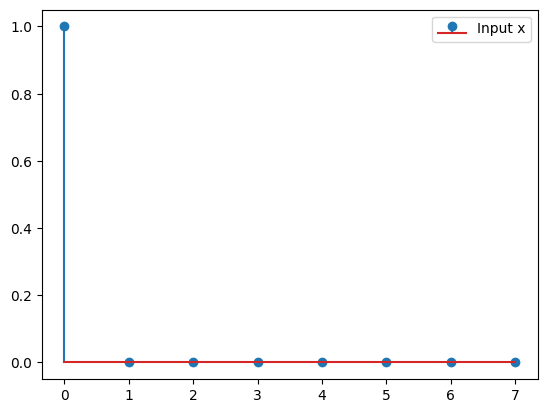

In [3]:
%matplotlib inline
plt.stem(signal.unit_impulse(8), label='Input x')
plt.legend()

查看一下 Jupyter 的版本。

In [ ]:
!jupyter --version

## DLTI 的两种基本形式：FIR 与 IIR

DLTI 系统有两种基本的形式，通常的名字是 FIR 与 IIR，主要区别是是系统否有记忆，即当前输出是否与过去的输出有关，还是只与输入有关。

FIR 其实就是加权移动平均（Weighted Moving Average, WMA for short）。

![FIR](data/fir.png)

$$\begin{aligned}
  y[n] &= \sum_{i=0}^{L}b[i] x[n-i] \\
       & = b[0]x[n] + b[1]x[n-1] + \cdots + b[L]x[n-L]
\end{aligned} $$


根据以上定义我们可以很容易写出自己的 WMA 实现，而 SciPy 里也有多种办法计算 WMA，包括

* [scipy.signal.convolve](https://docs.scipy.org/doc/scipy/reference/generated/scipy.signal.convolve.html), [oaconvolve](https://docs.scipy.org/doc/scipy/reference/generated/scipy.signal.oaconvolve.html), [fftconvolve](https://docs.scipy.org/doc/scipy/reference/generated/scipy.signal.fftconvolve.html)
* [scipy.signal.lfilter](https://docs.scipy.org/doc/scipy/reference/generated/scipy.signal.lfilter.html)
* [scipy.signal.dlsim](https://docs.scipy.org/doc/scipy/reference/generated/scipy.signal.dlsim.html)
* [scipy.signal.dlti.output](https://docs.scipy.org/doc/scipy/reference/generated/scipy.signal.dlti.output.html)

> FIR 其实也可以看成是最简单的前向神经网络，没有 bias，也没有 activation function，输出完全是输入按不同权重的线性组合。

WMA 的实现是两重循环，内循环负责加权求和，外循环负责移动。
以下代码的“加权求和”这一步用 `NumPy.dot()` 实现，比较简洁。
`dot()` 是计算两个向量的点积，也叫内积。

In [4]:
from typing import Sequence

def direct_wma(b : Sequence, x : Sequence) -> Sequence:
  y = np.zeros(len(x))
  x_pad = np.concatenate((np.zeros(len(b)-1), x))
  b_rev = np.array(b[::-1], dtype='d')
  for i in range(len(x)):
    y[i] = np.dot(b_rev, x_pad[i : i + len(b)])
  return y

用我们自己实现的 `direct_wma()` 来计算 $y[n] = 2x[n] + x[n-1]$.

In [5]:
b = [2, 1]
x = np.arange(10, dtype='d')
y = direct_wma(b, x)
print(np.array([x, y]).T)

[[ 0.  0.]
 [ 1.  2.]
 [ 2.  5.]
 [ 3.  8.]
 [ 4. 11.]
 [ 5. 14.]
 [ 6. 17.]
 [ 7. 20.]
 [ 8. 23.]
 [ 9. 26.]]


计算结果和 `scipy.signal.lfilter()` 是一致的。

In [6]:
# b 和 x 同上
y = signal.lfilter(b, [1], x)
print(np.array([x, y]).T)

[[ 0.  0.]
 [ 1.  2.]
 [ 2.  5.]
 [ 3.  8.]
 [ 4. 11.]
 [ 5. 14.]
 [ 6. 17.]
 [ 7. 20.]
 [ 8. 23.]
 [ 9. 26.]]


当然 `direct_wma()` 不是什么高效的实现，只是展示一下基本编程方法。

这个简单的系统可以用以下 block diagram 表示：

In [3]:
%load_ext tikzmagic

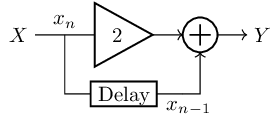

In [24]:
%%tikz -ct

\tikzset{european resistors};
\draw (0, 0) node [left] {$X$}
to [short] ++(0.5, 0) coordinate (In) node [above] {$x_{n}$};
\draw (In) [->] to [amp, t=2,] ++(2, 0)
node [adder,scale=0.6, anchor=w] (A){};
\draw (In) to [short] ++(0, -1) to [R=Delay,label distance=-13pt] ++(2, 0) coordinate (B)
 ++(0.1, 0) node [below] {$x_{n-1}$};;
\draw [->] (B) -| (A.s);
\draw [->] (A.e) to [short] ++(0.5, 0) node [right] {$Y$};

**第二种形式**，IIR，是在 FIR 的基础上，把过去的输出也用来计算新的输出。

![IIR](data/iir.png)

这种形式过去也叫梯子（ladder），或格子（lattice），是比较形象的说法。

$$\begin{aligned}
y[n] = &\sum_{i=0}^{L}b[i]x[n-i] - \sum_{i=1}^{M}a[i\,]y[n-i\,] \\
 = & \  b[0]x[n] + b[1]x[n-1] + \cdots + b[L]x[n-L] \\
        &-(a[1]y[n-1]+a[2]y[n-2]+\cdots+a[M]y[n-M])
\end{aligned}$$


SciPy 里提供了多种实现，本文以下主要使用第一个 `scipy.signal.lfilter()` 来计算输出，而用第三个 `scipy.signal.dlti` class 来分析离散线性时不变系统（频率响应、冲击响应、零极点等等）。

* [scipy.signal.lfilter](https://docs.scipy.org/doc/scipy/reference/generated/scipy.signal.lfilter.html)
* [scipy.signal.dlsim](https://docs.scipy.org/doc/scipy/reference/generated/scipy.signal.dlsim.html)
* [scipy.signal.dlti.output](https://docs.scipy.org/doc/scipy/reference/generated/scipy.signal.dlti.output.html)


有的领域把这种形式叫“自回归” autoregressive（特指用到当前输入和过去的输出），
如果同时用到了过去的输入和过去的输出，那和前面的移动平均合在一起，叫 [ARMA 模型](https://en.wikipedia.org/wiki/Autoregressive%E2%80%93moving-average_model)。

> 这也可以看成最简单的循环神经网络（RNN），没有 bias，也没有 activation function，只有两个权重。

我们自己实现 ARMA 也不难，用两个循环分别计算出第 1 项 sum 和第 2 项 sum，然后相减就得到了 $y[n]$。
稍有挑战的是如果输入是 Iterable，而不是 Sequence，那么该如何实现？
正式的系统一般会用循环缓冲区（circular buffer），我们自己练手写的话不妨粗放一些，直接用数组的

In [ ]:
# TODO

## Moving average

Julius O. Smith, _Introduction to Digital Filters with Audio Applications_, http://ccrma.stanford.edu/~jos/filters/

Chapter 1: https://ccrma.stanford.edu/~jos/filters/Simplest_Lowpass_Filter.html

### $N=2$

$y[n] = \dfrac{1}{2}x[n]+\dfrac{1}{2}x[n-1]$

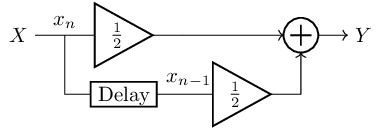

In [21]:
%%tikz -ct

\tikzset{european resistors};
\draw (0, 0) node [left] {$X$}
to [short] ++(0.5, 0) coordinate (In) node [above] {$x_n$}
to [amp, t={$\frac{1}{2}$},] ++(2, 0) coordinate (X0);

\draw (In) to [short] ++(0, -1) to [R=Delay,label distance=-13pt] ++(2, 0) coordinate(X1)
to [amp, t={$\frac{1}{2}$},] ++(2, 0) coordinate (B);
\draw (X1)++(0.1, 0) node [above] {$x_{n-1}$};
\draw (In -| B) node [adder,scale=0.6] (A){};
\draw [->] (X0) -- (A.w);
\draw [->] (B) -| (A.s);
\draw [->] (A.e) to [short] ++(0.5, 0) node [right] {$Y$};

**单位冲击响应** $h = [\frac{1}{2}, \frac{1}{2}]$

[[1.  0.5]
 [0.  0.5]
 [0.  0. ]
 [0.  0. ]
 [0.  0. ]
 [0.  0. ]
 [0.  0. ]
 [0.  0. ]]


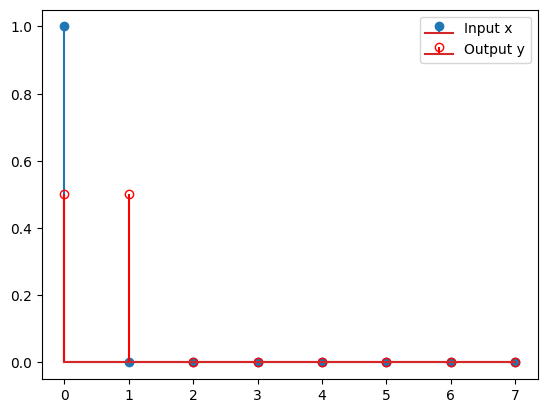

In [10]:
b = [1/2, 1/2]
x = signal.unit_impulse(8)
y = signal.lfilter(b, [1], x)

draw_resp_stem(x, y)
print(np.array([x, y]).T)

$N=2$ 的移动平均作用在等差数列上的效果：

In [4]:
x = np.arange(11)
y = signal.lfilter(b, [1], x)  # or signal.convolve(b, x)
print(np.array([x, y]).T)

[[ 0.   0. ]
 [ 1.   0.5]
 [ 2.   1.5]
 [ 3.   2.5]
 [ 4.   3.5]
 [ 5.   4.5]
 [ 6.   5.5]
 [ 7.   6.5]
 [ 8.   7.5]
 [ 9.   8.5]
 [10.   9.5]]


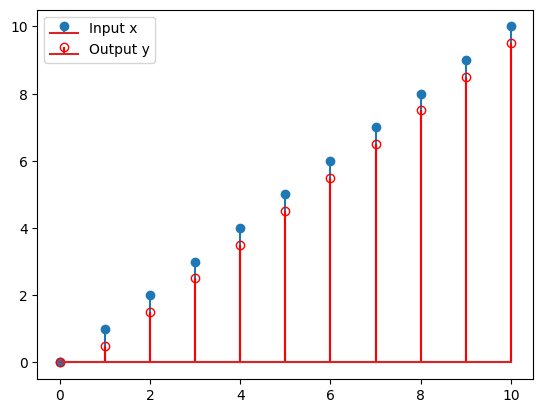

In [6]:
draw_resp_stem(x, y)

[scipy.signal.dlti](https://docs.scipy.org/doc/scipy/reference/generated/scipy.signal.dlti.html) Discrete-time linear time invariant system

**零极点图**显示这个系统有 1 个零点，位于 $(-1, 0)$.

Zeros: [-1.]
Poles: []


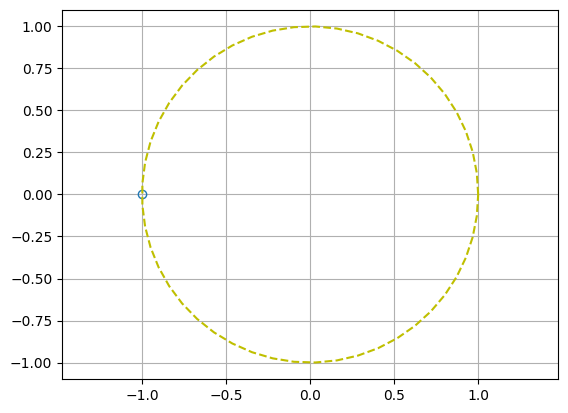

In [8]:
dlti = signal.dlti(b, [1])
print('Zeros:', dlti.zeros)
print('Poles:', dlti.poles)
draw_pzmap(dlti)

**频率响应**

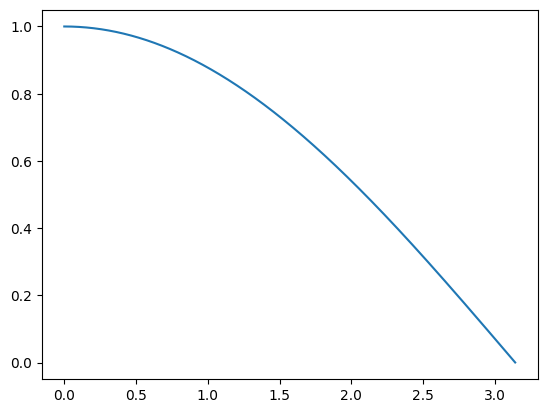

In [9]:
w, mag = dlti.freqresp()
plt.plot(w, np.abs(mag))

**波特图**

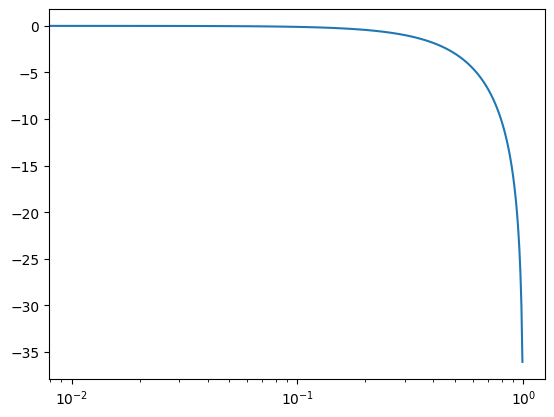

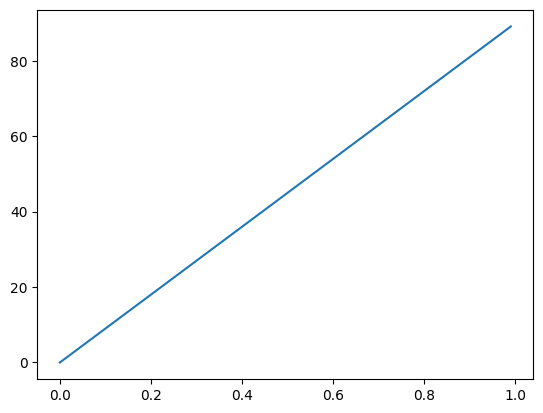

In [10]:
w, mag, phase = dlti.bode()
plt.semilogx(w/np.pi, mag)
plt.figure(2)
plt.plot(w/np.pi, phase)

零点位于 $(-1, 0)$，表示对于某种特定的输入 $x$，系统的响应是 $\boldsymbol 0$

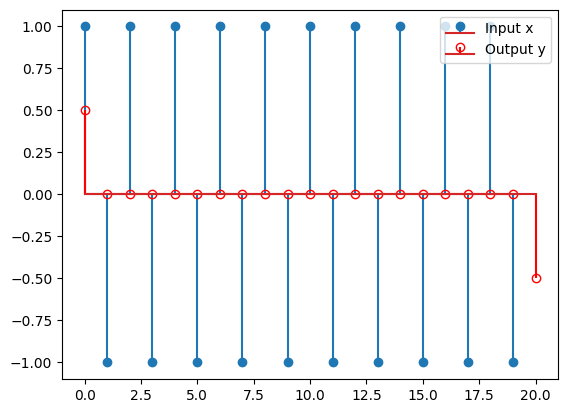

In [30]:
w = np.arange(20) * np.pi
x = np.cos(w)  # [1, -1, 1, -1, 1, -1, ...]
y = np.convolve(b, x)

draw_resp_stem(x, y)
#plt.stem(x, use_line_collection=True)
#(marker, _, _) = plt.stem(y, linefmt='r', markerfmt='ro', use_line_collection=True)
#marker.set_markerfacecolor('none')

需要运行以下 code 才能产生交互式的控件。

In [7]:
@interact(f = (0, 1, 0.02))
def resp(f = 0.5):
  t = np.linspace(0, 1, 101)
  x = np.cos(t * 2*np.pi * f * 100)
  plt.plot(t, x)
  y = signal.lfilter([1/2, 1/2], [1], x)
  plt.plot(t, y)
  plt.show()

interactive(children=(FloatSlider(value=0.5, description='f', max=1.0, step=0.02), Output()), _dom_classes=('w…

对冲击响应做 FFT 就能获得频率响应。

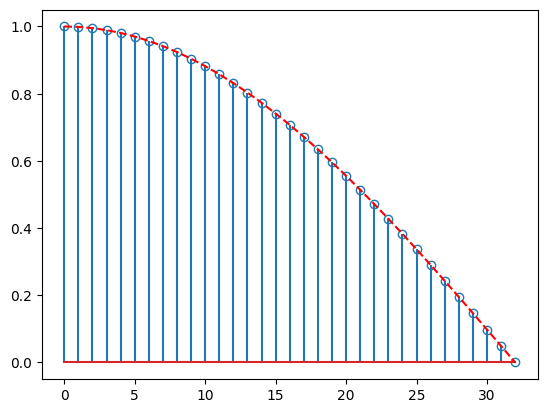

In [13]:
fft = np.fft.rfft([1/2, 1/2], n=64)  # zero padding
(marker, _, _) = plt.stem(np.abs(fft))
marker.set_markerfacecolor('none')

fr = dlti.freqresp(w=np.linspace(0, 1, len(fft)) * np.pi)[1]
plt.plot(np.abs(fr), 'r--')

### $N=3$

$y[n] = \dfrac{1}{3}x[n] + \dfrac{1}{3}x[n-1] + \dfrac{1}{3}x[n-2]$

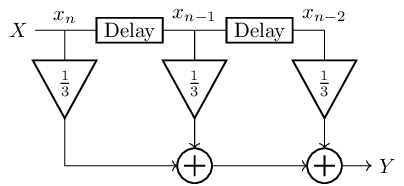

In [72]:
%%tikz -ct

\tikzset{european resistors};
\draw (0, 0) node [left] {$X$}
  to [short] ++(0.5, 0) coordinate (In) node [above] {$x_n$}
  to [R=Delay,label distance=-13pt] ++(2.2, 0) coordinate (X1) node [above] {$x_{n-1}$}
  to [R=Delay,label distance=-13pt] ++(2.2, 0) coordinate (X2) node [above] {$x_{n-2}$};

\draw [->] (X1) to [amp,n=M1] ++(0, -2) node [scale=0.6, adder, anchor=n] (A1) {};
\draw [->] (X2) to [amp,n=M2] ++(0, -2) node [scale=0.6, adder, anchor=n] (A2) {};
\draw [->] (In) to [amp,n=M0] ++(0, -2) to (In |- A1) to (A1.w);
\draw [->] (A1.e) to (A2.w);
\draw [->] (A2.e) to [short] ++(0.5, 0) node [right] {$Y$};
\draw (M0) ++(0, 0.1) node [] {$\frac{1}{3}$};
\draw (M1) ++(0, 0.1) node [] {$\frac{1}{3}$};
\draw (M2) ++(0, 0.1) node [] {$\frac{1}{3}$};

min_mag = -84.37 dB


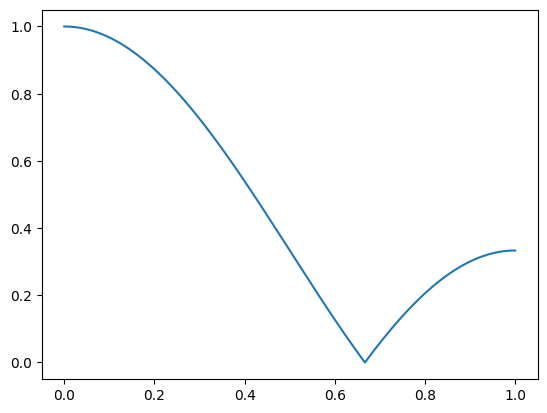

In [73]:
b3 = [1/3, 1/3, 1/3]
dlti3 = signal.dlti(b3, [1])

w, mag = dlti3.freqresp()
plt.plot(w/np.pi, np.abs(mag))
print('min_mag = %.2f dB' % (20 * np.log10(np.min(np.abs(mag)))))

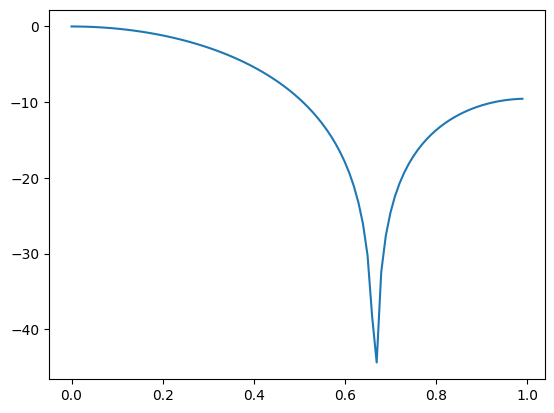

In [74]:
w, mag, phase = dlti3.bode()
plt.plot(w/np.pi, mag)

[ 120. -120.]


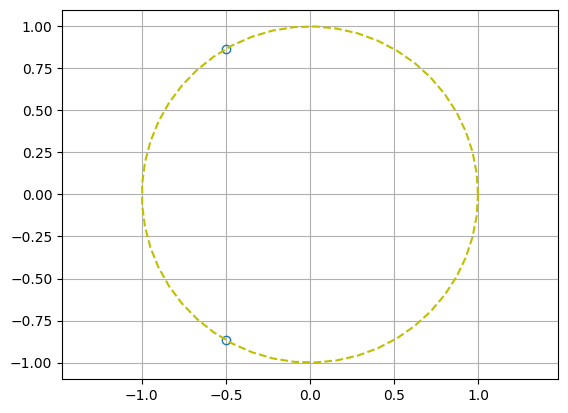

In [75]:
draw_pzmap(dlti3)
print(np.angle(dlti3.zeros)/np.pi*180)

[ 1.  -0.5 -0.5  1.  -0.5 -0.5  1.  -0.5 -0.5  1. ]


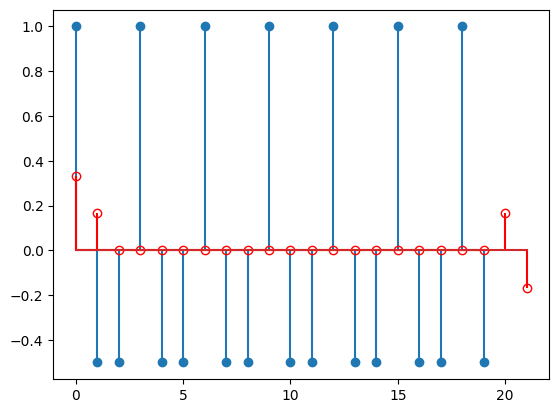

In [76]:
t = np.arange(20)
x = np.cos(t * 2/3 * np.pi)
y = np.convolve(x, b3)

draw_resp_stem(x, y)
print(x[0:10])

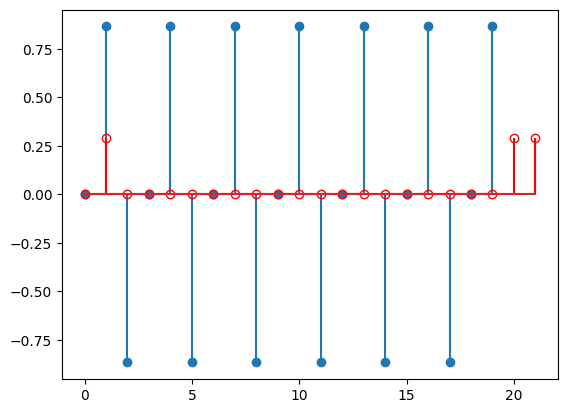

In [77]:
t = np.arange(20)
x = np.sin(t * 2/3 * np.pi)
y = np.convolve(x, b3)
draw_resp_stem(x, y)

# x = [1, -1, 0, 1, -1, 0, 1, -1, 0, 1]

In [78]:
@interact(phase=(0, 90, 5))
def resp(phase=45):
  t = np.arange(15)
  x = np.cos(t * 2/3 * np.pi - phase / 180 * np.pi)
  y = signal.lfilter(b3, [1], x)
  plt.stem(t, x)
  t1 = np.arange(141) / 10
  plt.plot(t1, np.cos(t1 * 2/3 * np.pi - phase / 180 * np.pi), 'y--')
  (markerline, stemlines, baseline) = plt.stem(t, y, linefmt='r', markerfmt='ro')
  markerline.set_markerfacecolor('none')

interactive(children=(IntSlider(value=45, description='phase', max=90, step=5), Output()), _dom_classes=('widg…

### $N=4$

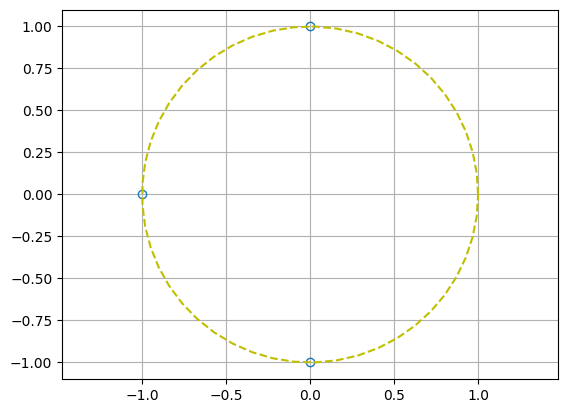

In [5]:
b4 = np.ones(4) / 4.0
dlti4 = signal.dlti(b4, [1])
draw_pzmap(dlti4)

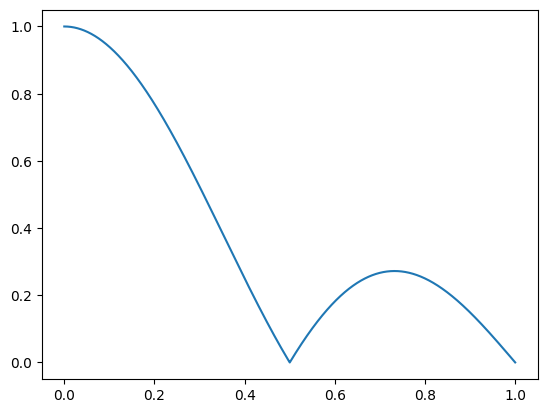

In [6]:
w, mag = dlti4.freqresp()
plt.plot(w/np.pi, np.abs(mag))

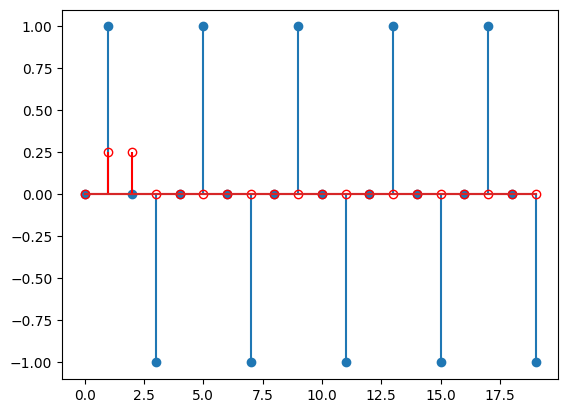

In [7]:
x = np.array([0, 1, 0, -1] * 5)
y = signal.lfilter(b4, [1], x)

draw_resp_stem(x, y)

In [8]:
@interact(phase=(0, 90, 5))
def resp(phase=30):
  t = np.arange(16)
  x = np.cos(t * 1/2 * np.pi - phase / 180 * np.pi)
  y = signal.lfilter(b4, [1], x)
  plt.stem(t, x)
  t1 = np.arange(151) / 10
  plt.plot(t1, np.cos(t1 * 1/2 * np.pi - phase / 180 * np.pi), 'y--')
  (markerline, stemlines, baseline) = plt.stem(t, y, linefmt='r', markerfmt='ro')
  markerline.set_markerfacecolor('none')

interactive(children=(IntSlider(value=30, description='phase', max=90, step=5), Output()), _dom_classes=('widg…

## Differentiator

$y[n]=x[n]-x[n-1]$

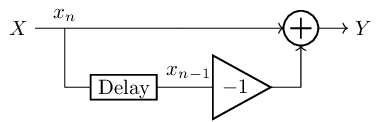

In [29]:
%%tikz -ct

\tikzset{european resistors};
\draw (0, 0) node [left] {$X$}
to [short] ++(0.5, 0) coordinate (In) node [above] {$x_n$}
to ++(2, 0) coordinate (X0);

\draw (In) to [short] ++(0, -1) to [R=Delay,label distance=-13pt] ++(2, 0) coordinate(X1)
to [amp, t={$-1$},] ++(2, 0) coordinate (B);
\draw (X1)++(0.1, 0) node [above] {$x_{n-1}$};
\draw (In -| B) node [adder,scale=0.6] (A){};
\draw [->] (X0) -- (A.w);
\draw [->] (B) -| (A.s);
\draw [->] (A.e) to [short] ++(0.5, 0) node [right] {$Y$};

In [12]:
bd = [1, -1]
x = np.arange(10, dtype='d')  ** 2 
print(x)
y = signal.lfilter(bd, [1], x)
print(y)
z = signal.lfilter(bd, [1], y)
print(z)
z = signal.lfilter(bd, [1], z)
print(z)

[ 0.  1.  4.  9. 16. 25. 36. 49. 64. 81.]
[ 0.  1.  3.  5.  7.  9. 11. 13. 15. 17.]
[0. 1. 2. 2. 2. 2. 2. 2. 2. 2.]
[0. 1. 1. 0. 0. 0. 0. 0. 0. 0.]


单位冲击响应

[[ 1.  1.]
 [ 0. -1.]
 [ 0.  0.]
 [ 0.  0.]
 [ 0.  0.]
 [ 0.  0.]
 [ 0.  0.]
 [ 0.  0.]]


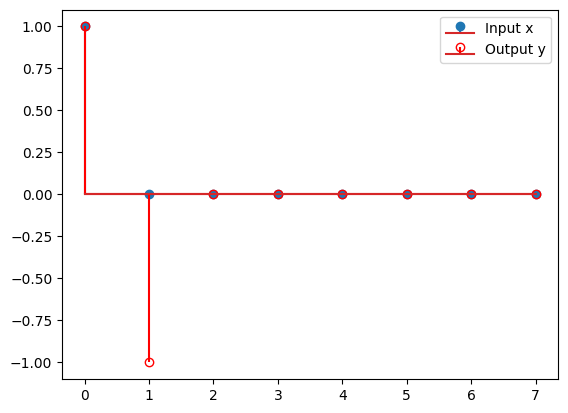

In [13]:
x = signal.unit_impulse(8)
y = signal.lfilter(bd, [1], x)

draw_resp_stem(x, y)
print(np.array([x, y]).T)

阶跃响应

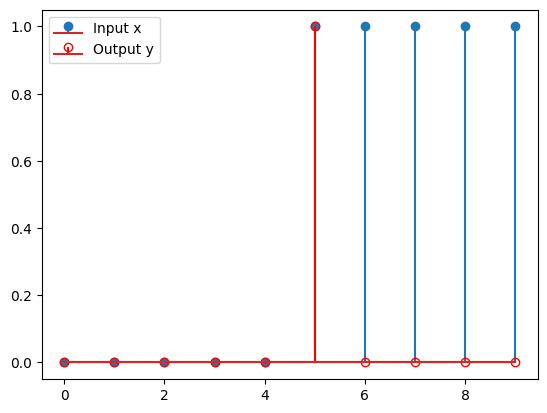

In [16]:
x = np.concatenate([np.zeros(5), np.ones(5)])
y = signal.lfilter(bd, [1], x)

draw_resp_stem(x, y)

Zeros: [1.]
Poles: []


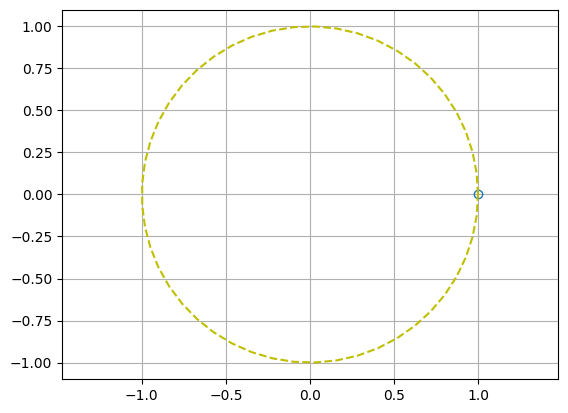

In [15]:
dlti = signal.dlti(bd, [1])
zeros = dlti.zeros
print('Zeros:', zeros)
print('Poles:', dlti.poles)
draw_pzmap(dlti)

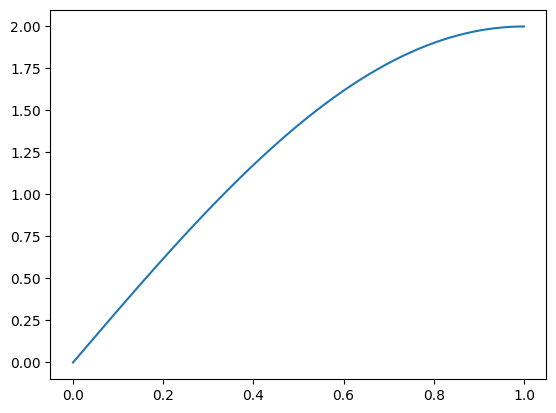

In [16]:
w, mag = dlti.freqresp()
plt.plot(w/np.pi, np.abs(mag))

### Eigenfunction

In [17]:
x = 2.0 ** np.arange(14)

y = signal.lfilter(bd, [1], x)
z = signal.lfilter(bd, [1], y)
w = signal.lfilter(bd, [1], z)
np.array([x, y, z, w]).T

array([[   1.,    1.,    1.,    1.],
       [   2.,    1.,    0.,   -1.],
       [   4.,    2.,    1.,    1.],
       [   8.,    4.,    2.,    1.],
       [  16.,    8.,    4.,    2.],
       [  32.,   16.,    8.,    4.],
       [  64.,   32.,   16.,    8.],
       [ 128.,   64.,   32.,   16.],
       [ 256.,  128.,   64.,   32.],
       [ 512.,  256.,  128.,   64.],
       [1024.,  512.,  256.,  128.],
       [2048., 1024.,  512.,  256.],
       [4096., 2048., 1024.,  512.],
       [8192., 4096., 2048., 1024.]])

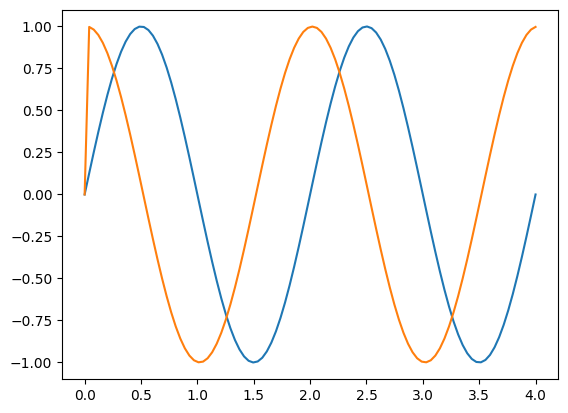

In [18]:
t = np.linspace(0, 1,100) * 4 * np.pi
x = np.sin(t)
y = signal.lfilter(bd, [1], x)
plt.plot(t/np.pi, x)
plt.plot(t/np.pi, y/(t[1]-t[0]))

# Autoregressive

本节内容视频讲解：https://youtu.be/NXnkhopsUnE 国内：[自回归](https://www.bilibili.com/video/BV1FW4y1U7dY)

![IIR](data/iir.png)

$$\begin{aligned}
y[n] = &\sum_{i=0}^{L}b[i]x[n-i] - \sum_{i=1}^{M}a[i\,]y[n-i\,] \\[2mm]
 = & \  b[0]x[n] + b[1]x[n-1] + \cdots + b[L]x[n-L] \\
        &-(a[1]y[n-1]+a[2]y[n-2]+\cdots+a[M]y[n-M])
\end{aligned}$$



## Accumulator, integrator

$y[n] = x[n] + y[n-1]$

$H(z)=\dfrac{1}{1-z^{-1}}$

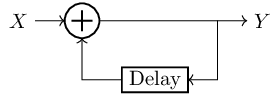

In [27]:
%%tikz -ct -l arrows -p blox

\tikzset{european resistors};
\draw [->] (0, 0) node [left] {$X$}
to [short] ++(0.5, 0) node [adder,scale=0.6,anchor=w] (A) {};
\draw [->] (A.e) to ++(2, 0) coordinate (X0) 
  to [short] ++(0.5, 0) node [right] {$Y$};
%coordinate (In) node [above] {$x_n$}

\draw [->] (X0) to [short] ++(0, -1) to ++(-0.5, 0) coordinate(X1);
\draw [->] (X1) to [R, n=R] ++(-1.12, 0) -| (A.s);
\draw (R) node {Delay};

Zeros: []
Poles: [1.]


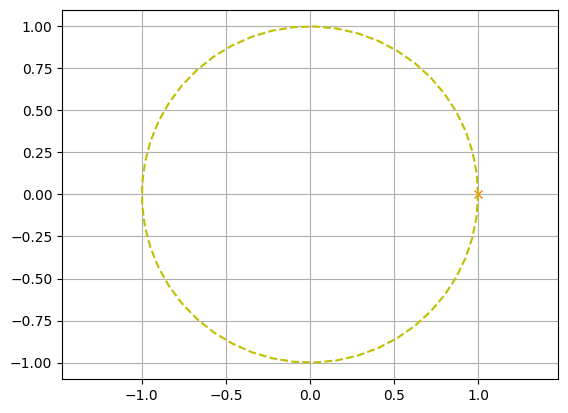

In [14]:
dlti = signal.dlti([1], [1, -1])
draw_pzmap(dlti)
print('Zeros:', dlti.zeros)
print('Poles:', dlti.poles)

In [12]:
b = [1]
a = [1, -1]
x = np.zeros(11)
x[1] = 1
print(x)
y = signal.lfilter(b, a, x=x)
print(y)
z = signal.lfilter(b, a, y)
print(z)
w = signal.lfilter(b, a, z)
print(w)

[0. 1. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
[0. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]
[ 0.  1.  2.  3.  4.  5.  6.  7.  8.  9. 10.]
[ 0.  1.  3.  6. 10. 15. 21. 28. 36. 45. 55.]


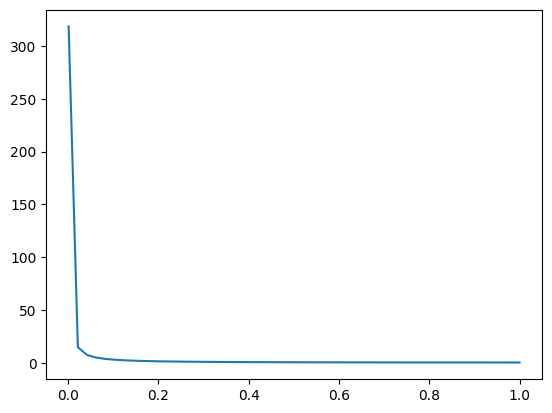

In [19]:
w, mag = dlti.freqresp(w=np.linspace(np.pi/1000, np.pi))
plt.plot(w/np.pi, np.abs(mag))

<StemContainer object of 3 artists>

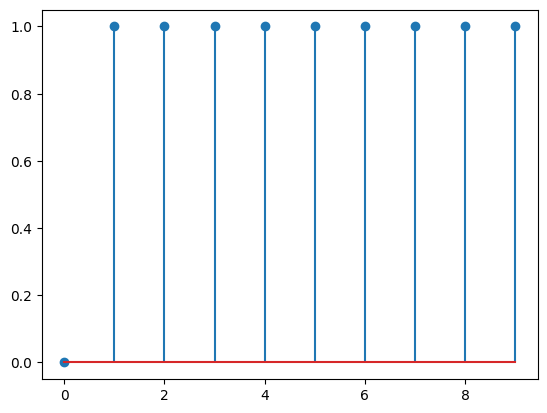

In [15]:
t, y = dlti.impulse(n=10)
plt.stem(t, y[0])

<StemContainer object of 3 artists>

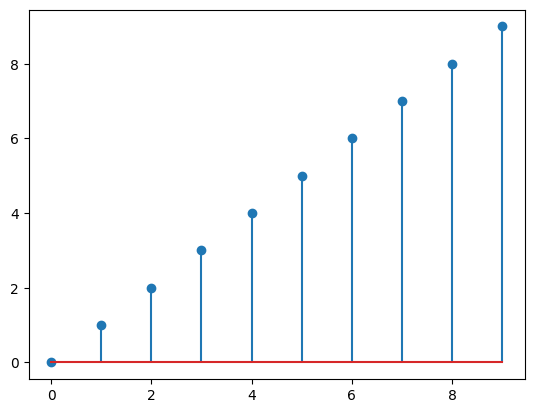

In [16]:
t, y = dlti.step(n=10)
plt.stem(t, y[0])

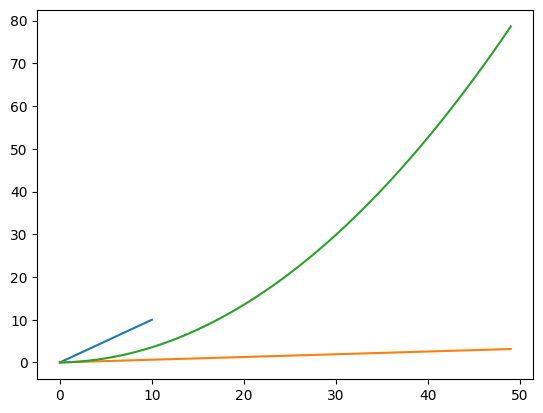

In [22]:
w3 = signal.lfilter(b, a, w)
plt.plot(z)   # linear
plt.plot(w)   # quadratic
plt.plot(w3)  # 3-order

#### Eigenfunction

In [ ]:
x = 2.0 ** np.arange(11)
y = signal.lfilter(b, a, x, zi=x[0:1])[0]
z = signal.lfilter(b, a, y, zi=y[0:1])[0]
w = signal.lfilter(b, a, z, zi=z[0:1])[0]
np.array([x, y, z, w]).T

In [ ]:
t = np.linspace(0, 1,100) * 4 * np.pi
x = np.sin(t)
y = signal.lfilter(b, a, x)
plt.plot(t/np.pi, x)
plt.plot(t/np.pi, y*(t[1]-t[0]))

模拟反向积分器

![](data/integrator.png)

https://en.wikipedia.org/wiki/Integrator


$$V_\text{out}(t_1) = V_\text{out}(t_0) - \frac{1}{RC} \int_{t_0}^{t_1} V_\text{in}(t) \,dt$$

* R = 1 MΩ
* C = 1 μF
* Vin = 1 V (DC)
* Ir = 1 μA
* Vout = -t V
* Vs = ±15V

那么积十几秒就会饱和。

OPA627
* Vos = 100 μV
* Ib = 1 pA

## Compound interest

$y[n] = x[n] + a y[n-1]$

$H(z)=\dfrac{1}{1-az^{-1}}$

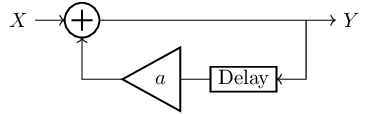

In [35]:
%%tikz -ct -l arrows -p blox

\tikzset{european resistors};
\draw [->] (0, 0) node [left] {$X$}
to [short] ++(0.5, 0) node [adder,scale=0.6,anchor=w] (A) {};
\draw [->] (A.e) to ++(3.5, 0) coordinate (X0) 
  to [short] ++(0.5, 0) node [right] {$Y$};
%coordinate (In) node [above] {$x_n$}

\draw [->] (X0) to [short] ++(0, -1) to ++(-0.5, 0) coordinate(X1);
\draw [->] (X1) to [R, n=R] ++(-1.12, 0) 
 to [amp,n=M] ++(-2, 0) -| (A.s);
\draw (R) node {Delay};
\draw (M) node [right=-2pt] {$a$};

Zeros: []
Poles: [1.1]


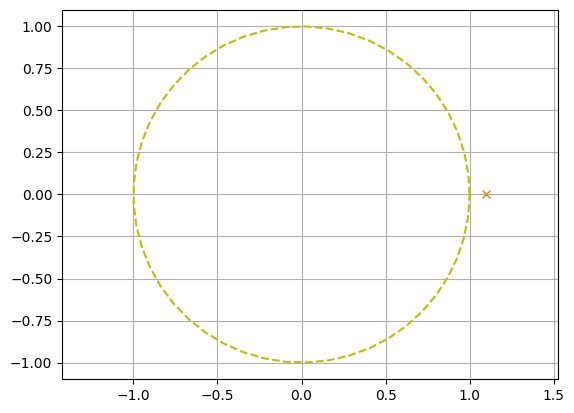

In [23]:
a = 1.1  # 年投资回报率 10%

dlti = signal.dlti([1], [1, -a])
draw_pzmap(dlti)
print('Zeros:', dlti.zeros)
print('Poles:', dlti.poles)

<StemContainer object of 3 artists>

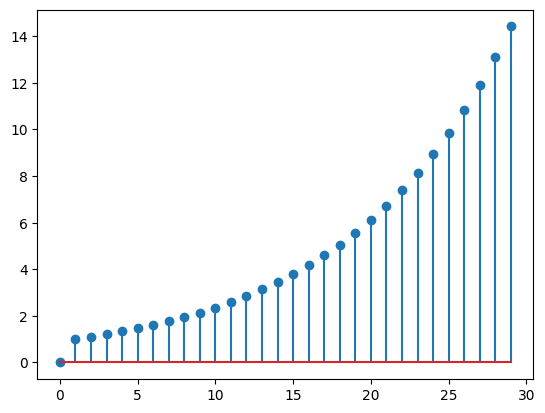

In [24]:
t, y = dlti.impulse(n=30)
plt.stem(t, y[0])

<StemContainer object of 3 artists>

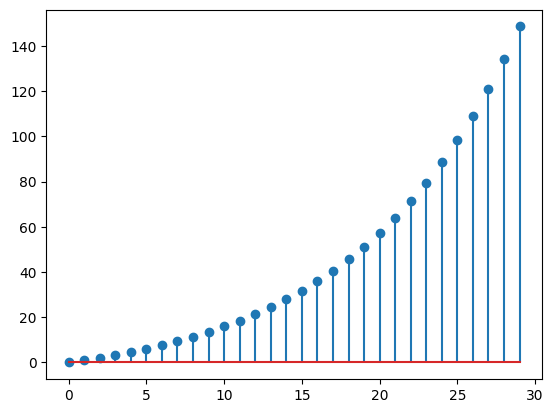

In [25]:
t, y = dlti.step(n=30)
plt.stem(t, y[0])

#### 零状态响应

年息 1.2%，月息 0.1%，每月存 1000。$a = 1+ 1.2\% / 12 = 1.001$

In [26]:
rate = 1.2
a = 1.0 + rate / 100 / 12

x = np.ones(12) * 1000
y = signal.lfilter([1], [1, -a], x)
print(np.array([x, np.round(y, 2)]).T)

[[ 1000.    1000.  ]
 [ 1000.    2001.  ]
 [ 1000.    3003.  ]
 [ 1000.    4006.  ]
 [ 1000.    5010.01]
 [ 1000.    6015.02]
 [ 1000.    7021.04]
 [ 1000.    8028.06]
 [ 1000.    9036.08]
 [ 1000.   10045.12]
 [ 1000.   11055.17]
 [ 1000.   12066.22]]


#### 零输入响应

年息 1.2%，月息 0.1%，起始存款 10000。

In [27]:
rate = 1.2
a = 1.0 + rate / 100 / 12
y0 = 10000.0

x = np.zeros(13) * 0.0
y, yn = signal.lfilter([1], [1, -a], x, zi=[y0])
np.set_printoptions(suppress=True)
print(np.array([np.arange(len(x)), np.round(y, 2)]).T)
# print('yn =', np.round(yn, 2))

[[    0.   10000.  ]
 [    1.   10010.  ]
 [    2.   10020.01]
 [    3.   10030.03]
 [    4.   10040.06]
 [    5.   10050.1 ]
 [    6.   10060.15]
 [    7.   10070.21]
 [    8.   10080.28]
 [    9.   10090.36]
 [   10.   10100.45]
 [   11.   10110.55]
 [   12.   10120.66]]


#### 完全响应

贷款 20000，年息 3.5%，分 24 期（2 年）偿还，每月还款 864.06。

$p = L\dfrac{c(1+c)^n}{(1+c)^n-1}$, $L=20\,000$, $n = 24$, $c = 3.5\%/12$.

In [28]:
L = 20000
n = 24
rate = 3.5
c = rate / 100 / 12
p = L * c * np.power(1+c, n) / (np.power(1+c, n) - 1)
print('Monthly payment: %.4f' % p)

Monthly payment: 864.0544


In [29]:
rate = 3.5
a = 1.0 + rate / 100 / 12
y0 = 20000.0

x = np.concatenate(([0.0], np.ones(24) * -864.06))
y, yn = signal.lfilter([1], [1, -a], x, zi=[y0])
np.set_printoptions(suppress=True)
print(np.array([np.arange(len(x)), np.round(y, 2)]).T)
print('yn =', np.round(yn, 2))

[[    0.   20000.  ]
 [    1.   19194.27]
 [    2.   18386.2 ]
 [    3.   17575.76]
 [    4.   16762.97]
 [    5.   15947.8 ]
 [    6.   15130.25]
 [    7.   14310.32]
 [    8.   13488.  ]
 [    9.   12663.28]
 [   10.   11836.15]
 [   11.   11006.62]
 [   12.   10174.66]
 [   13.    9340.28]
 [   14.    8503.46]
 [   15.    7664.2 ]
 [   16.    6822.49]
 [   17.    5978.33]
 [   18.    5131.71]
 [   19.    4282.62]
 [   20.    3431.05]
 [   21.    2577.  ]
 [   22.    1720.45]
 [   23.     861.41]
 [   24.      -0.14]]
yn = [-0.14]



## Exponential moving average

$y[n] = ax[n]+(1-a)y[n-1]$

$H(z) = \dfrac{a}{1 - (1-a)z^{-1}}$

证明：对于 x[n] = constant, y[n] 收敛到 constant。

$H(1) = \dfrac{a}{1-(1-a)} = \dfrac{a}{a} = 1$, if $a \ne 0$

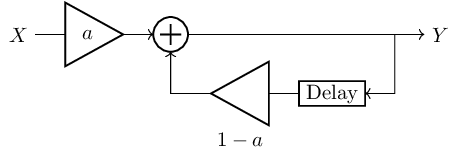

In [48]:
%%tikz -ct -l arrows -p blox

\tikzset{european resistors};
\draw [->] (0, 0) node [left] {$X$}
to [amp,n=M0] ++(2, 0) node [adder,scale=0.6,anchor=w] (A) {};
\draw [->] (A.e) to ++(3.5, 0) coordinate (X0) 
  to [short] ++(0.5, 0) node [right] {$Y$};
%coordinate (In) node [above] {$x_n$}

\draw [->] (X0) to [short] ++(0, -1) to ++(-0.5, 0) coordinate(X1);
\draw [->] (X1) to [R, n=R] ++(-1.12, 0) 
 to [amp,n=M,l=$1-a$] ++(-2, 0) -| (A.s);
\draw (R) node {Delay};
\draw (M0) node [left=-3pt]{$a$};

Zeros: []
Poles: [0.2]


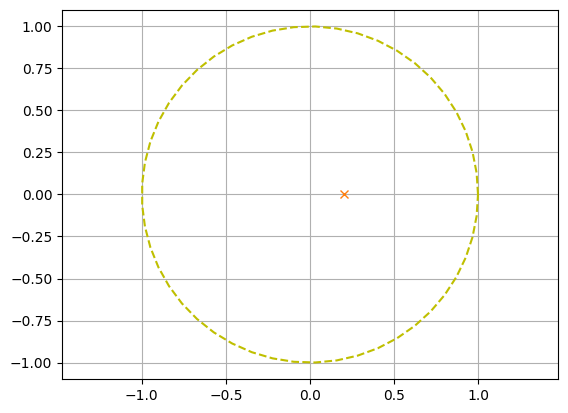

In [30]:
a = 0.8

dlti = signal.dlti([a], [1, a-1])
draw_pzmap(dlti)
print('Zeros:', dlti.zeros)
print('Poles:', dlti.poles)

In [31]:
@interact(a=(0.1, 0.9, 0.1))
def ema(a):
  dlti = signal.dlti([a], [1, a-1])
  t, imp = dlti.impulse()
  plt.stem(t, imp[0])
  plt.figure(2)
  t, step = dlti.step()
  plt.stem(t, step[0])

interactive(children=(FloatSlider(value=0.5, description='a', max=0.9, min=0.1), Output()), _dom_classes=('wid…

In [32]:
@interact(a=(0.1, 0.9, 0.1))
def ema(a):
  dlti = signal.dlti([a], [1, a-1])
  draw_pzmap(dlti)
  plt.figure(2)
  w, mag = dlti.freqresp()
  plt.plot(w/np.pi, np.abs(mag))
  plt.ylim(0, 1.1)

interactive(children=(FloatSlider(value=0.5, description='a', max=0.9, min=0.1), Output()), _dom_classes=('wid…

#### How does TCP calculates RTT

TODO

## Fibonacci sequence

$y[n] = y[n-1] + y[n-2]$, with $y[-1] = 1$

$H(z) = \dfrac{1}{1-z^{-1}-z^{-2}}$

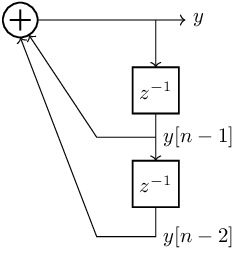

In [32]:
%%tikz -ct -l calc,math,arrows -p blox

\draw node [adder,scale=0.6] (A){};
\draw [->] (A.e) -- ++(2, 0) coordinate (Y) -- ++(0.5, 0) node [right] {$y$};
\draw [->] (Y) -- ++(0, -0.8) node [twoportshape, scale=0.8, anchor=n] (D1) {};
\draw (D1) node {$z^{-1}$};
\draw [->] (D1.s) -- ++(0, -0.8) node [twoportshape, scale=0.8, anchor=n] (D2) {};
\draw (D2) node {$z^{-1}$};
\draw [->] ($(D1.s)!0.5!(D2.n)$) node [right] {$y[n-1]$} -- ++(-1, 0) -- (A.300);
\draw [->] (D2.s) -- ++(0, -0.5) node [right] {$y[n-2]$} -- ++(-1, 0) -- (A.s);

Zeros: []
Poles: [ 1.61803399 -0.61803399]


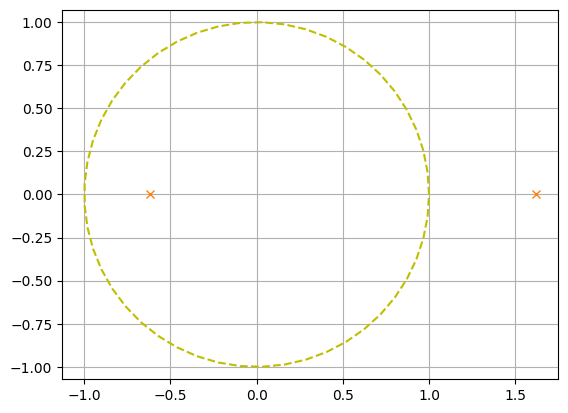

In [5]:
dlti = signal.dlti([1], [1, -1, -1])
draw_pzmap(dlti)
print('Zeros:', dlti.zeros)
print('Poles:', dlti.poles)

In [34]:
dlti.impulse(n=15)[1]

(array([[  0.],
        [  0.],
        [  1.],
        [  1.],
        [  2.],
        [  3.],
        [  5.],
        [  8.],
        [ 13.],
        [ 21.],
        [ 34.],
        [ 55.],
        [ 89.],
        [144.],
        [233.]]),)

## Second order digital sinusoidal oscillator

$y[n]=2\cos(w)y[n-1]-y[n-2]$, with $y[-1] = \sin(w)$

$H(z) = \dfrac{1}{1-2\cos(w)z^{-1}+z^{-2}}$

* Digital resonator
https://ccrma.stanford.edu/~jos/pdf/GordonAndSmith86.pdf
* [MIT OCW 6.003](https://ocw.mit.edu/courses/6-003-signals-and-systems-fall-2011/pages/readings/) notes [Chap 6 - The perfect (sine) wave](https://ocw.mit.edu/courses/6-003-signals-and-systems-fall-2011/resources/mit6_003f11_chap6/) using [leapfrog method](https://en.wikipedia.org/wiki/Leapfrog_integration).

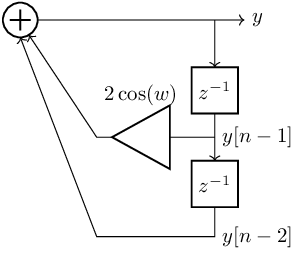

In [51]:
%%tikz -ct -l calc,math,arrows -p blox

\draw node [adder,scale=0.6] (A){};
\draw [->] (A.e) -- ++(3, 0) coordinate (Y) -- ++(0.5, 0) node [right] {$y$};
\draw [->] (Y) -- ++(0, -0.8) node [twoportshape, scale=0.8, anchor=n] (D1) {};
\draw (D1) node {$z^{-1}$};
\draw [->] (D1.s) -- ++(0, -0.8) node [twoportshape, scale=0.8, anchor=n] (D2) {};
\draw (D2) node {$z^{-1}$};
\draw [->] ($(D1.s)!0.5!(D2.n)$) node [right] {$y[n-1]$} -- ++(-0.5, 0) to [amp, n=C] ++(-1.5, 0) -- (A.300);
\draw (C) node [above=12pt] {{$2\cos(w)$}};
\draw [->] (D2.s) -- ++(0, -0.5) node [right] {$y[n-2]$} -- ++(-2, 0) -- (A.s);

Zeros: []
Poles: [0.95105652+0.30901699j 0.95105652-0.30901699j] [1. 1.]
Poles amp: [1. 1.] angle: [ 18. -18.]


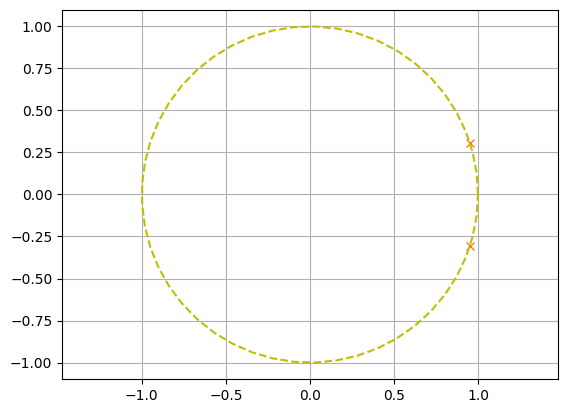

In [57]:
w = np.pi / 10
dlti = signal.dlti([1], [1, -2 * np.cos(w), 1])
draw_pzmap(dlti)
print('Zeros:', dlti.zeros)
print('Poles:', dlti.poles, np.abs(dlti.poles))
print('Poles amp:', np.abs(dlti.poles), "angle:", np.angle(dlti.poles) / np.pi * 180)

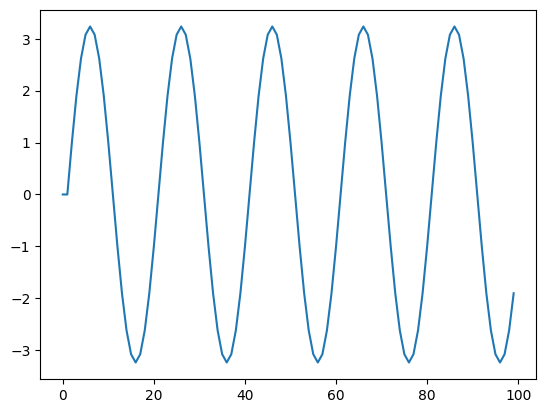

In [49]:
y = dlti.impulse()[1]
plt.plot(y[0])

0.9980267284282738 -0.9980267284282742


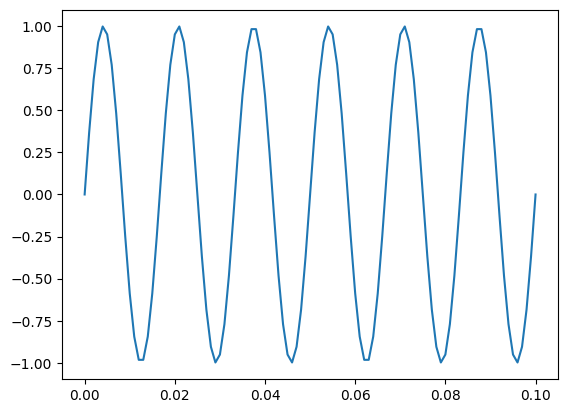

In [37]:
# This is numerically instable

fs = 1000
f = 60
w = 2*np.pi*f/fs
c = np.cos(w)
a = [1, -2*c, 1]
n = 101
x = np.zeros(n) * 0.0
y0 = np.sin(w)
y, yn = signal.lfilter([1], a, x, zi=[0, y0])
t = np.arange(n)/fs
plt.plot(t, y)
print(max(y), min(y))

# Summary


单输入单输出（SISO）的 DLTI 系统可由 $\mathbf{a}, \mathbf{b}$ 两个向量，总共 $L+M+1$ 个系数完全定义：

![IIR](data/iir.png)


$$\begin{aligned}
y[n] = &\sum_{i=0}^{L}b[i]x[n-i] - \sum_{i=1}^{M}a[i\,]y[n-i\,] \\[2mm]
 = & \  b[0]x[n] + b[1]x[n-1] + \cdots + b[L]x[n-L] \\
        &-(a[1]y[n-1]+a[2]y[n-2]+\cdots+a[M]y[n-M])
\end{aligned}$$


**注解**

1. LTI 是 Linear Time-Invariant 的首字母缩写，现在一般统一按字面意思翻译为“线性时不变”，有些比较旧的书上也叫“线性定常”。
2. 离散 LTI，有的书也叫线性移不变 （Linear Shift-Invariant)

### DLTI 系统模型之间的相互转换

![DLTI](data/dlti.png)

$$\begin{aligned}
y[n] &= \sum_{i=0}^{L}b_ix[n-i\,] - \sum_{i=1}^{M}a_iy[n-i\,] \\
     &=  \  b_0x[n] + b_1x[n-1] + \cdots + b_Lx[n-L] \\
     & \quad   -(a_1y[n-1]+a_2y[n-2]+\cdots+a_My[n-M])\\[3mm]
H(z) &= \frac{\sum_{i=0}^{L}b_iz^{-i}}{1+ \sum_{i=1}^{M}a_iz^{-i}} \\
     &= \frac{b_0 + b_1z^{-1}+b_2z^{-2}+\cdots+b_Lz^{-L}}{1+a_1z^{-1}+a_2z^{-2}+\cdots+a_Mz^{-M}}\\[3mm]
H(z) &= b_0\frac{\prod_{i=1}^L(1-z_iz^{-1})}{\prod_{i=1}^M(1-p_iz^{-1})} \\
     &=b_0\frac{(1-z_1z^-1)(1-z_2z^{-1})\cdots(1-z_Lz^{-1})}{(1-p_1z^-1)(1-p_2z^{-1})\cdots(1-z_Mz^{-1})}
\end{aligned}$$

本套实验没有使用 $z$ 变换分析 DLTI 系统，这种方法在一般的教材上都会介绍，我就不费口舌了。比如
https://web.eecs.umich.edu/~fessler/course/451/l/pdf/c3.pdf